# AI4I 2020 Predictive Maintenance Dataset
## Data Preprocessing, Cleaning & Exploratory Data Analysis (EDA)

**Purpose of this notebook**

Before we can build classification models such as **Logistic Regression** or **SVM** to predict machine failure, we need to understand the data and prepare it properly. This notebook covers everything that happens *before* modelling:

1. Loading the data
2. Initial inspection (structure, types, size)
3. Data cleaning (missing values, duplicates, data-leakage columns)
4. Exploratory Data Analysis (EDA) — univariate, bivariate and multivariate
5. Outlier detection
6. Feature engineering & encoding
7. Feature scaling
8. Train/test split
9. Exporting a clean, model-ready dataset

**Why this matters for the models we plan to build**

- **Logistic Regression** or **SVM** are both distance/gradient based algorithms. They assume numeric input, are sensitive to the *scale* of features (a feature measured in the thousands, like rotational speed, would dominate one measured in single digits, like tool wear, if left unscaled), and cannot directly use text/categorical columns.
- Both algorithms can also be affected by **outliers** and by **irrelevant / leaking columns** (columns that leak the answer), so we must identify and deal with these before training.
- The dataset target (`Machine failure`) is **highly imbalanced** (~3.4% failures), which is important to know before choosing an evaluation strategy and possibly a resampling technique.

Each step below includes **what we did and why**, so this notebook can be walked through when explaining the workflow to a lecturer or teammate.


## 1. Dataset Source

**Dataset:** [AI4I 2020 Predictive Maintenance Dataset](https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset) (UCI Machine Learning Repository, ID = 601)

It is a **synthetic dataset** (10,000 rows, 14 columns) built to mimic a real industrial milling machine, created by S. Matzka (2020). Because it is synthetic, it is clean by design (no missing values / no duplicates), but we still perform every check a real project would require — this is good practice and also lets us confirm the claim rather than assume it.

We load it using the official `ucimlrepo` package, exactly as recommended on the UCI page.


In [40]:
# Install the official UCI ML Repository client (only needs to run once)
# !pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

# fetch dataset
try:
    ai4i_2020_predictive_maintenance_dataset = fetch_ucirepo(id=601)

    # data (as pandas dataframes)
    X = ai4i_2020_predictive_maintenance_dataset.data.features
    y = ai4i_2020_predictive_maintenance_dataset.data.targets

    # metadata & variable information (useful for the report / lecturer)
    print(ai4i_2020_predictive_maintenance_dataset.metadata.name)
    print(ai4i_2020_predictive_maintenance_dataset.metadata.abstract[:400], "...")
    display(ai4i_2020_predictive_maintenance_dataset.variables)
except Exception as e:
    # e.g. no internet connection in this environment -- the fallback cell below
    # reads the same data from a local CSV instead so the notebook still runs.
    print("Could not reach the UCI server (this just needs an internet connection):", e)


AI4I 2020 Predictive Maintenance Dataset
The AI4I 2020 Predictive Maintenance Dataset is a synthetic dataset that reflects real predictive maintenance data encountered in industry. ...


,name,role,type,demographic,description,units,missing_values
0,UID,ID,Integer,None,None,None,no
1,Product ID,ID,Categorical,None,None,None,no
2,Type,Feature,Categorical,None,None,None,no
3,Air temperature,Feature,Continuous,None,None,K,no
4,Process temperature,Feature,Continuous,None,None,K,no
5,Rotational speed,Feature,Integer,None,None,rpm,no
6,Torque,Feature,Continuous,None,None,Nm,no
7,Tool wear,Feature,Integer,None,None,min,no
8,Machine failure,Target,Integer,None,None,None,no
9,TWF,Target,Integer,None,None,None,no


## 2. Initial Inspection

Before touching the data, we look at its **shape, column types, and basic statistics**. This tells us what cleaning is even needed — there is no point cleaning something that is already clean, and we should never assume, we should check.


In [64]:
print("Shape (rows, columns):", df.shape)
df.info()


Shape (rows, columns): (10000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
 7   TWF                  10000 non-null  int64  
 8   HDF                  10000 non-null  int64  
 9   PWF                  10000 non-null  int64  
 10  OSF                  10000 non-null  int64  
 11  RNF                  10000 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 937.6+ KB


In [65]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature,10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature,10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed,10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque,10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear,10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.0,0.0,0.0,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.0,0.0,0.0,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.0,0.0,0.0,1.0
OSF,10000.0,0.00980,0.098514,0.0,0.0,0.0,0.0,1.0


**What we're checking here:**
- `df.info()` shows column data types (numeric vs text) and non-null counts per column. If `non-null count < number of rows`, that column has missing values.
- `df.describe()` gives min/max/mean/std for numeric columns — useful for spotting impossible values (e.g. negative temperature in Kelvin, negative torque) which would indicate data entry errors.


## 3. Data Cleaning

### 3.1 Missing values


In [44]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})


,missing_count,missing_%
Type,0,0.0
Air temperature,0,0.0
Process temperature,0,0.0
Rotational speed,0,0.0
Torque,0,0.0
Tool wear,0,0.0
Machine failure,0,0.0
TWF,0,0.0
HDF,0,0.0
PWF,0,0.0


**Result:** There are **no missing values** in any column. This is expected since the dataset is synthetically generated and pre-cleaned by its creators. In a real-world dataset we would now decide, column-by-column, whether to *impute* (mean/median/mode) or *drop* rows/columns with missing data — but that step is not needed here. We still show the check so the process is complete and auditable.

### 3.2 Duplicate rows

In [45]:
num_duplicates = df.duplicated().sum()
print(f"Number of fully duplicated rows: {num_duplicates}")


Number of fully duplicated rows: 0


**Result:** No duplicate rows. Good — duplicates can bias a model by over-weighting repeated observations, but there is nothing to remove here.

### 3.3 Impossible / out-of-range values

Even without missing data, we should sanity-check that physical quantities make sense (e.g. temperature in Kelvin must be > 0, torque and rotational speed must be positive, tool wear can't be negative).

In [46]:
numeric_cols = ["Air temperature", "Process temperature", "Rotational speed",
                "Torque", "Tool wear"]

for col in numeric_cols:
    print(f"{col:28s} min={df[col].min():>8.2f}  max={df[col].max():>8.2f}")

Air temperature              min=  295.30  max=  304.50
Process temperature          min=  305.70  max=  313.80
Rotational speed             min= 1168.00  max= 2886.00
Torque                       min=    3.80  max=   76.60
Tool wear                    min=    0.00  max=  253.00


**Result:** All values are within physically sensible ranges (positive temperatures, positive torque/speed, non-negative tool wear). No impossible values found.

### 3.4 Identifier columns

`UDI` (a row counter) and `Product ID` (a unique serial number per part, e.g. `M14860`) are **unique identifiers**. They carry no predictive information about failure — a model that used them would just be memorising row numbers, which would not generalise to new machines. We will drop them before modelling (kept for now, dropped explicitly in the Feature Engineering section below).

In [47]:
if "UDI" in df.columns:
    print("Unique UDI values:", df["UDI"].nunique(), "out of", len(df))
if "Product ID" in df.columns:
    print("Unique Product ID values:", df["Product ID"].nunique(), "out of", len(df))
# Note: UDI and Product ID columns not present in this dataset version

### 3.5 Data leakage columns — `TWF`, `HDF`, `PWF`, `OSF`, `RNF`

These five columns record *which specific failure mode* occurred (Tool Wear Failure, Heat Dissipation Failure, Power Failure, Overstrain Failure, Random Failure). Our target, `Machine failure`, is **defined as 1 exactly when at least one of these five flags is 1** — i.e. these columns are a *decomposition of the target itself*, not independent input features.

If we left them in as predictors, the model would essentially be shown the answer (e.g. `if HDF==1 then Machine failure==1` almost always) and would get unrealistically high accuracy that would **not** reflect real-world performance, where these flags would not be known in advance. This is a classic case of **data leakage**, and these columns must be dropped from the feature set before training `X`. We keep them only for EDA (e.g. to see which failure mode is most common) and drop them right before modelling.


In [48]:
failure_mode_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

# sanity check: machine failure should equal an OR of the 5 flags
check = (df[failure_mode_cols].sum(axis=1) > 0).astype(int)
mismatch = (check != df["Machine failure"]).sum()
print(f"Rows where Machine failure label disagrees with OR of the 5 sub-flags: {mismatch}")


Rows where Machine failure label disagrees with OR of the 5 sub-flags: 27


## 4. Target Variable Analysis

Understanding the balance of the target class is essential — it changes how we evaluate a model later (accuracy becomes misleading on imbalanced data; precision/recall/F1/ROC-AUC become more informative), and can motivate techniques such as `class_weight='balanced'` in Logistic Regression/SVM or resampling (SMOTE, undersampling) at the modelling stage.


Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    96.61
1     3.39
Name: count, dtype: float64


C:\Users\gprud\AppData\Local\Temp\ipykernel_30492\388437595.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Machine failure", data=df, ax=axes[0], palette=["#4C72B0", "#DD8452"])
C:\Users\gprud\AppData\Local\Temp\ipykernel_30492\388437595.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No Failure (0)", "Failure (1)"])


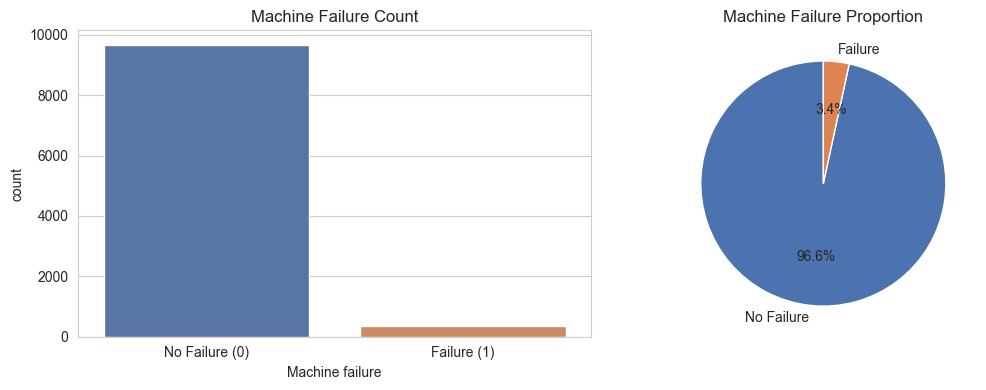

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

fail_counts = df["Machine failure"].value_counts().sort_index()
fail_pct = (fail_counts / len(df) * 100).round(2)
print(fail_counts)
print(fail_pct)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="Machine failure", data=df, ax=axes[0], palette=["#4C72B0", "#DD8452"])
axes[0].set_title("Machine Failure Count")
axes[0].set_xticklabels(["No Failure (0)", "Failure (1)"])

axes[1].pie(fail_counts, labels=["No Failure", "Failure"], autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90)
axes[1].set_title("Machine Failure Proportion")
plt.tight_layout()
plt.show()


**Observation:** Only about **3.4% of machines failed** (339 out of 10,000). This is a **severely imbalanced classification problem**. Take-away for modelling: plain accuracy would be misleading (a model predicting "no failure" every time would score ~96.6% accuracy while being useless), so later we will need to look at precision/recall/F1/ROC-AUC and consider `class_weight="balanced"` or resampling.

### Breakdown of failures by failure mode

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64


C:\Users\gprud\AppData\Local\Temp\ipykernel_30492\2809259895.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mode_counts.index, y=mode_counts.values, palette="viridis")


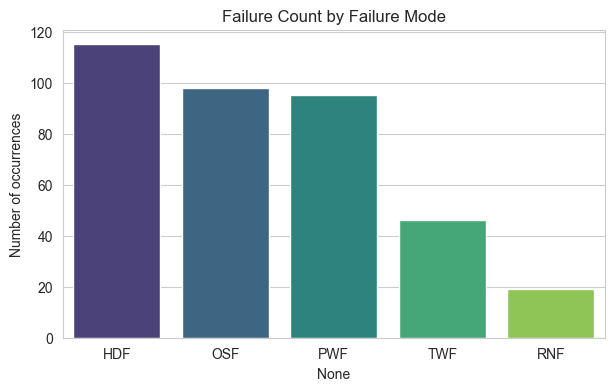

In [50]:
mode_counts = df[failure_mode_cols].sum().sort_values(ascending=False)
print(mode_counts)

plt.figure(figsize=(7,4))
sns.barplot(x=mode_counts.index, y=mode_counts.values, palette="viridis")
plt.title("Failure Count by Failure Mode")
plt.ylabel("Number of occurrences")
plt.show()


**Observation:** Heat Dissipation Failure (HDF) and Power Failure (PWF) are the most common failure modes, followed by Overstrain (OSF), Tool Wear (TWF), and rare Random Failures (RNF). This context is useful discussion material, even though these columns are dropped before modelling (see §3.5).

## 5. Univariate EDA — Numeric Features

We look at the distribution (histogram) and spread (boxplot) of each numeric sensor reading, to understand its shape (normal? skewed?) and to visually spot outliers.


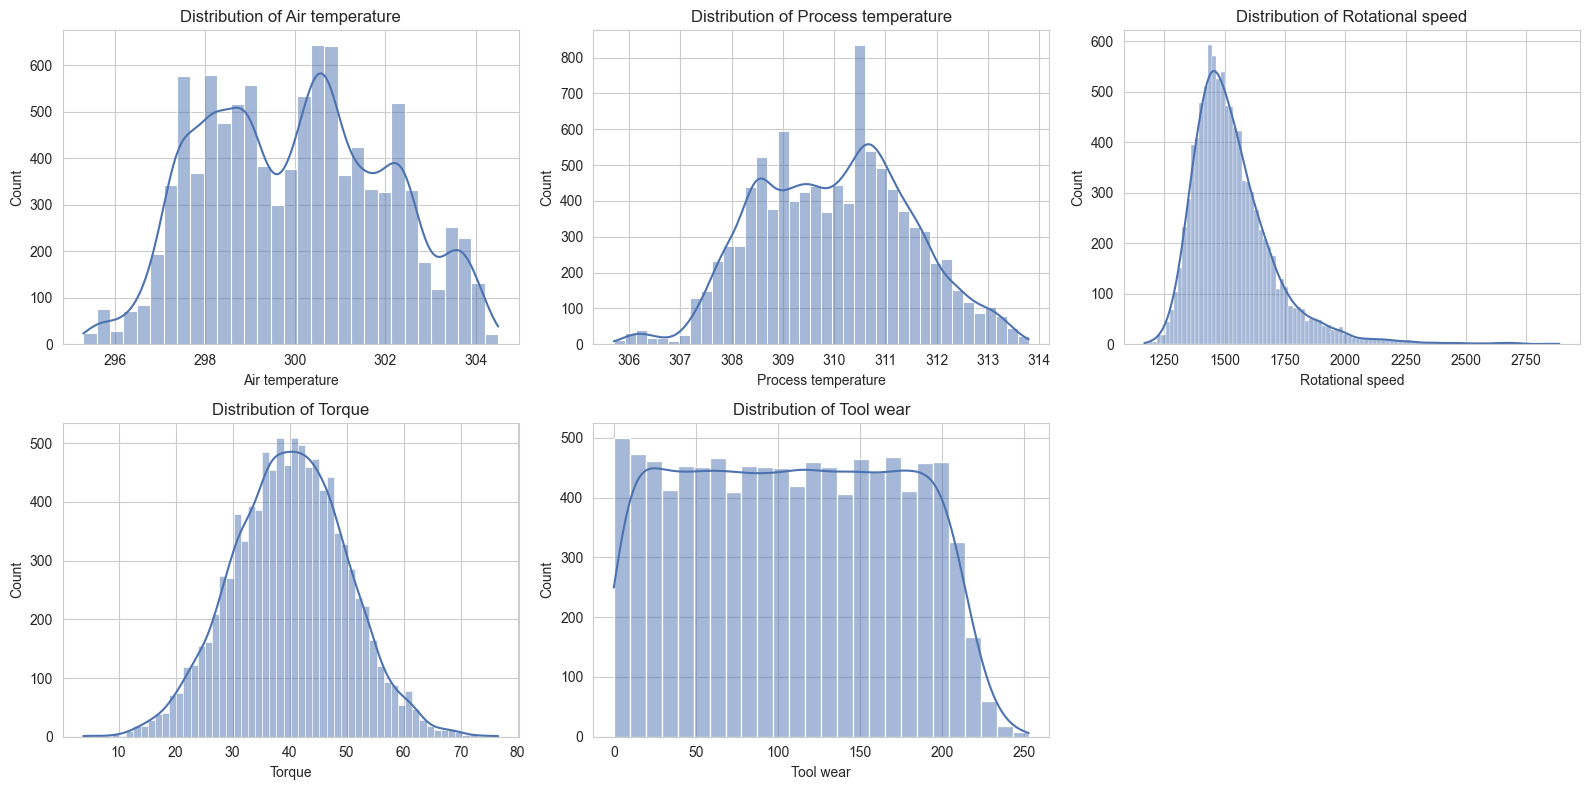

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Distribution of {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()


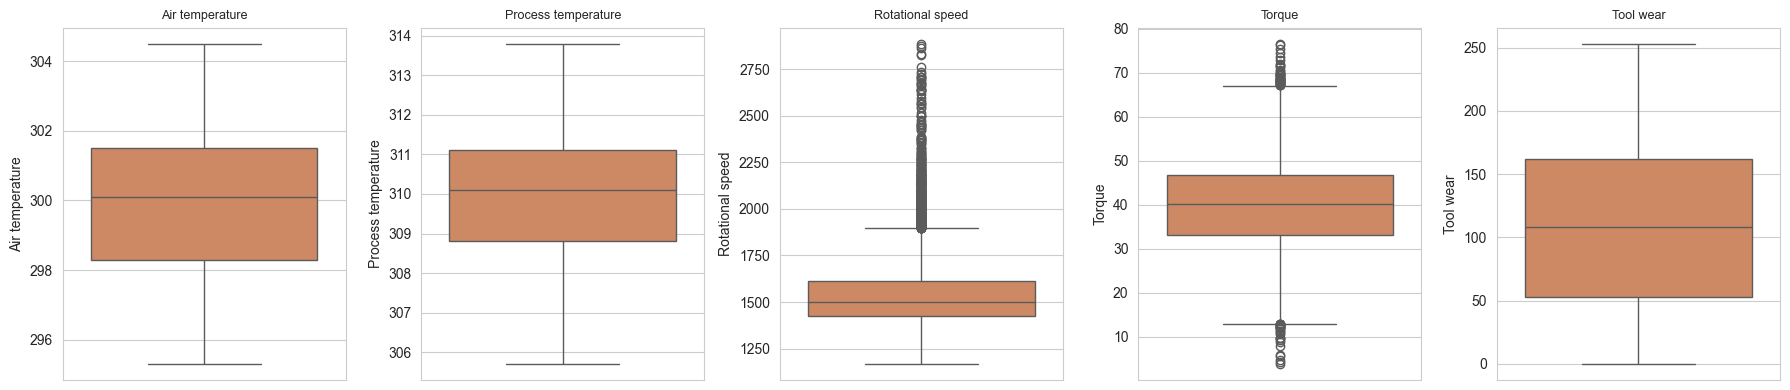

In [52]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#DD8452")
    axes[i].set_title(col, fontsize=9)
plt.tight_layout()
plt.show()


**Observations:**
- `Air temperature [K]` and `Process temperature [K]` are roughly normally distributed (they were generated by the dataset authors via a random-walk process), and process temperature ≈ air temperature + 10K, so we'd expect them to be correlated (checked in §7).
- `Rotational speed [rpm]` is right-skewed with a handful of high-value outliers (visible as points above the boxplot whisker) — it was derived from *power ÷ speed*, so very low or high speeds at fixed power create a long tail.
- `Torque [Nm]` looks close to normal, centred near 40 Nm.
- `Tool wear [min]` is close to uniform (linearly ramps from 0 up to ~250 minutes since it represents accumulated wear time before a tool is replaced).

We'll quantify the outliers next using the IQR method.


### Outlier detection using the IQR (Interquartile Range) method

A common, robust rule: any value more than `1.5 × IQR` below Q1 or above Q3 is flagged as an outlier. This does **not** mean we automatically delete these rows — outliers can be genuine rare (but valid) machine states, especially since 3.4% of rows are genuine failures which naturally sit at the extremes of these sensor readings. We first *measure* how many there are, then make an informed decision.

In [53]:
def iqr_outlier_summary(frame, cols):
    rows = []
    for c in cols:
        q1, q3 = frame[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((frame[c] < low) | (frame[c] > high)).sum()
        rows.append([c, round(low, 2), round(high, 2), n_out, round(n_out / len(frame) * 100, 2)])
    return pd.DataFrame(rows, columns=["feature", "lower_bound", "upper_bound", "n_outliers", "pct_outliers"])

outlier_summary = iqr_outlier_summary(df, numeric_cols)
outlier_summary


,feature,lower_bound,upper_bound,n_outliers,pct_outliers
0,Air temperature,293.50,306.30,0,0.00
1,Process temperature,305.35,314.55,0,0.00
2,Rotational speed,1139.50,1895.50,418,4.18
3,Torque,12.80,67.20,69,0.69
4,Tool wear,-110.50,325.50,0,0.00


In [54]:
# How many of the outlier rows are actually failures? (checks whether outliers ~= real failure signal)
outlier_mask = pd.Series(False, index=df.index)
for c in numeric_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_mask |= (df[c] < low) | (df[c] > high)

print(f"Rows flagged as outliers on at least one feature: {outlier_mask.sum()} ({outlier_mask.mean()*100:.2f}%)")
print("Failure rate inside outlier rows: {:.2f}%".format(df.loc[outlier_mask, "Machine failure"].mean()*100))
print("Failure rate outside outlier rows: {:.2f}%".format(df.loc[~outlier_mask, "Machine failure"].mean()*100))


Rows flagged as outliers on at least one feature: 459 (4.59%)
Failure rate inside outlier rows: 15.69%
Failure rate outside outlier rows: 2.80%


**Decision on outliers:** The failure rate is much higher *inside* the flagged outlier rows than outside. This tells us these "outliers" are largely **genuine extreme operating conditions that precede failure** — exactly the signal we want the model to learn — not measurement errors. **We therefore do not remove them.** Removing them would delete a large share of the minority (failure) class and destroy the very information the classifier needs. (This is a judgement call we explain explicitly to the lecturer: statistical outlier ≠ data error.)

## 6. Categorical Feature EDA — `Type`

`Type` records the product quality variant: **L**ow, **M**edium, **H**igh.


Type
L    6000
M    2997
H    1003
Name: count, dtype: int64
Type
L    60.0
M    30.0
H    10.0
Name: count, dtype: float64


C:\Users\gprud\AppData\Local\Temp\ipykernel_30492\2026033434.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Type", data=df, order=["L","M","H"], palette="Set2")


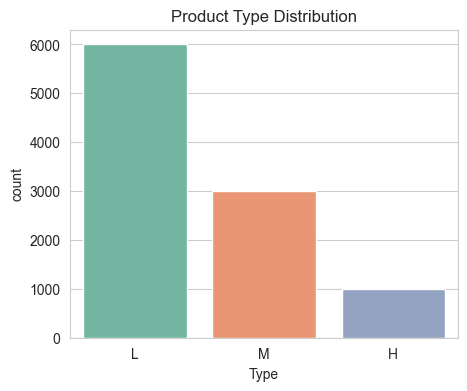

In [55]:
type_counts = df["Type"].value_counts()
print(type_counts)
print((type_counts / len(df) * 100).round(1))

plt.figure(figsize=(5,4))
sns.countplot(x="Type", data=df, order=["L","M","H"], palette="Set2")
plt.title("Product Type Distribution")
plt.show()


**Observation:** matches the documentation exactly — 50% Low, 30% Medium, 20% High quality parts. No unexpected categories/typos found (a good check to always do on categorical text columns — e.g. `" L"` vs `"L"` vs `"l"` would silently create fake extra categories).

### Failure rate by product Type

C:\Users\gprud\AppData\Local\Temp\ipykernel_30492\476493618.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fail_by_type.index, y="failure_rate", data=fail_by_type.reset_index(), palette="Set2")


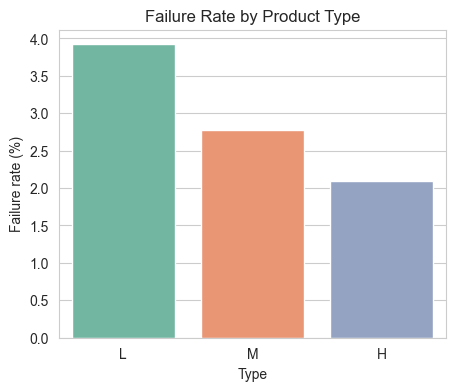

In [56]:
fail_by_type = df.groupby("Type")["Machine failure"].agg(["mean", "count"]).rename(columns={"mean": "failure_rate"})
fail_by_type["failure_rate"] = (fail_by_type["failure_rate"] * 100).round(2)
fail_by_type = fail_by_type.reindex(["L", "M", "H"])
fail_by_type

plt.figure(figsize=(5,4))
sns.barplot(x=fail_by_type.index, y="failure_rate", data=fail_by_type.reset_index(), palette="Set2")
plt.ylabel("Failure rate (%)")
plt.title("Failure Rate by Product Type")
plt.show()


**Observation:** Low-quality (`L`) parts fail somewhat more often than Medium/High quality parts. This makes physical sense (lower-quality tools add less wear margin before failure per the dataset design) and tells us `Type` is a potentially useful predictor, so we keep and encode it.

## 7. Bivariate / Multivariate EDA

### 7.1 Correlation heatmap (numeric features + target)

This shows linear relationships between features (helps spot **multicollinearity**, which particularly affects Logistic Regression's coefficient stability) and between each feature and the target (a first hint of predictive value).


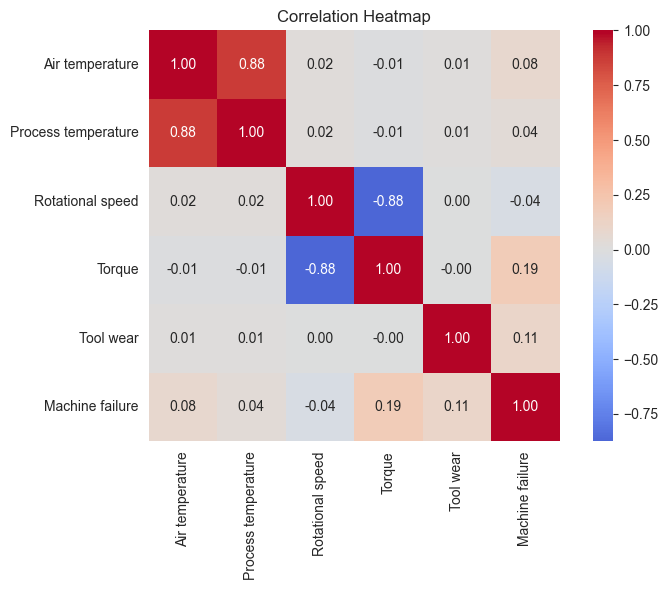

In [57]:
corr_cols = numeric_cols + ["Machine failure"]
corr = df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


**Observations:**
- `Air temperature [K]` and `Process temperature [K]` are **strongly correlated** (as expected, since process temp = air temp + ~10K by construction). This is multicollinearity — worth knowing about for Logistic Regression (coefficients can become unstable / hard to interpret when two features are almost redundant), though it usually doesn't hurt raw predictive accuracy much. We flag it here and could consider dropping one or combining them into a temperature-difference feature (done in §8).
- `Rotational speed [rpm]` and `Torque [Nm]` are **negatively correlated**, consistent with them being derived from a roughly constant mechanical power (power ≈ speed × torque).
- `Torque [Nm]` has the strongest (positive) correlation with `Machine failure` among the raw numeric features, followed by `Tool wear [min]` — both plausible physically (overstrain/tool-wear failure modes).


### 7.2 Feature distributions split by failure outcome

Boxplots comparing each sensor reading for failed vs non-failed machines — this is the clearest way to see which features actually separate the two classes (i.e. which features the model is likely to find useful).

C:\Users\gprud\AppData\Local\Temp\ipykernel_30492\1411722465.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Machine failure", y=col, data=df, ax=axes[i], palette=["#4C72B0", "#DD8452"])
C:\Users\gprud\AppData\Local\Temp\ipykernel_30492\1411722465.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No Failure", "Failure"])
C:\Users\gprud\AppData\Local\Temp\ipykernel_30492\1411722465.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Machine failure", y=col, data=df, ax=axes[i], palette=["#4C72B0", "#DD8452"])
C:\Users\gprud\AppData\Local\Temp\ipykernel_30492\1411722465.p

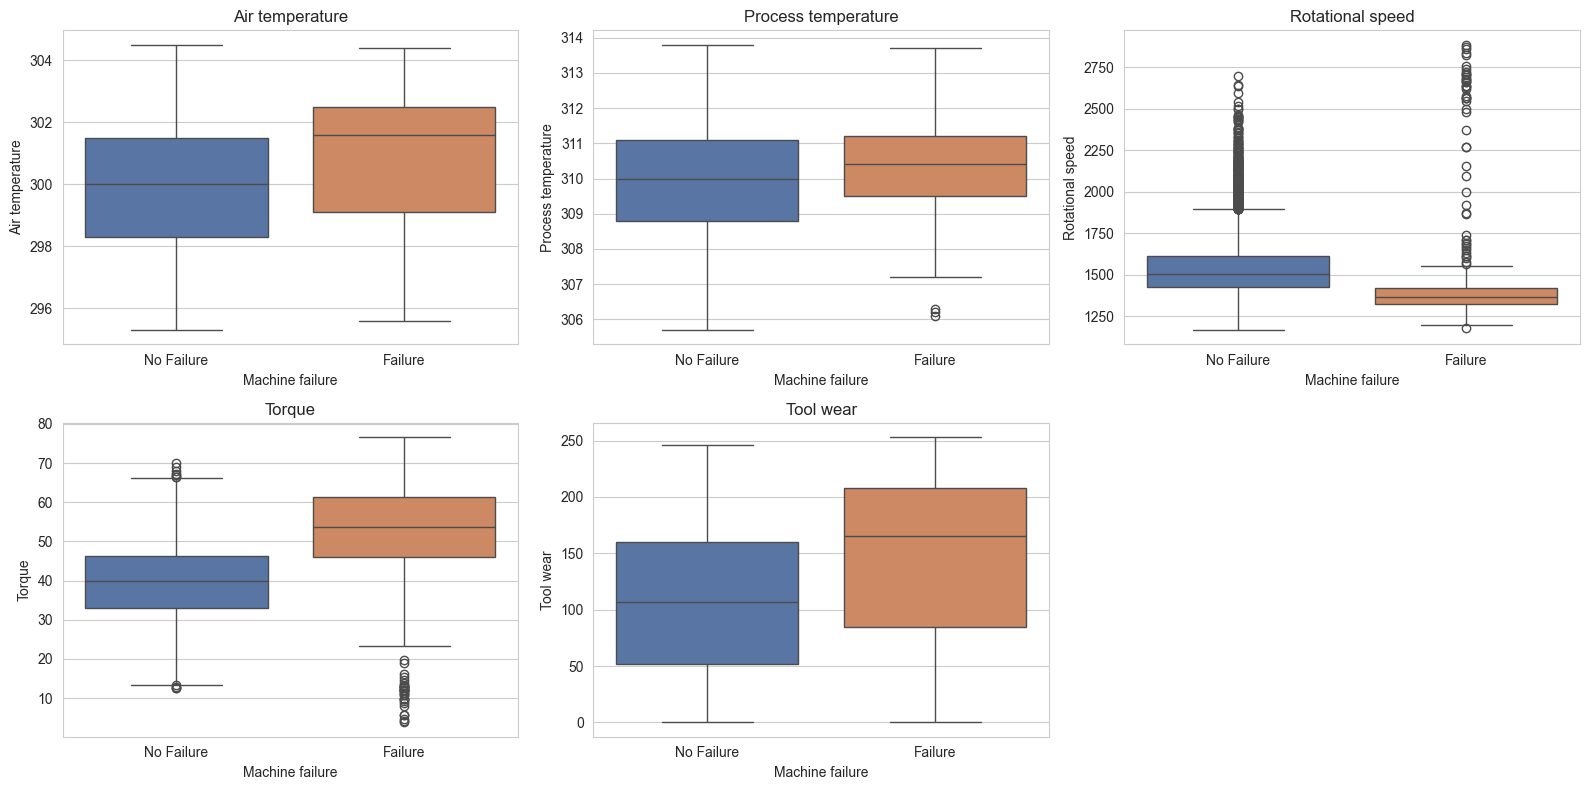

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x="Machine failure", y=col, data=df, ax=axes[i], palette=["#4C72B0", "#DD8452"])
    axes[i].set_xticklabels(["No Failure", "Failure"])
    axes[i].set_title(col)
axes[-1].axis("off")
plt.tight_layout()
plt.show()


**Observations:** Failed machines show a noticeably **wider spread of torque** (both very low and very high torque relate to failure — consistent with power-failure logic: too low or too high power both fail) and **higher tool wear** on average (consistent with tool-wear/overstrain failure logic). Temperatures are similar between the two classes but with more high-temperature outliers among failures (heat-dissipation failure). This confirms these features carry real predictive signal.

### 7.3 Pairwise relationships (sampled)

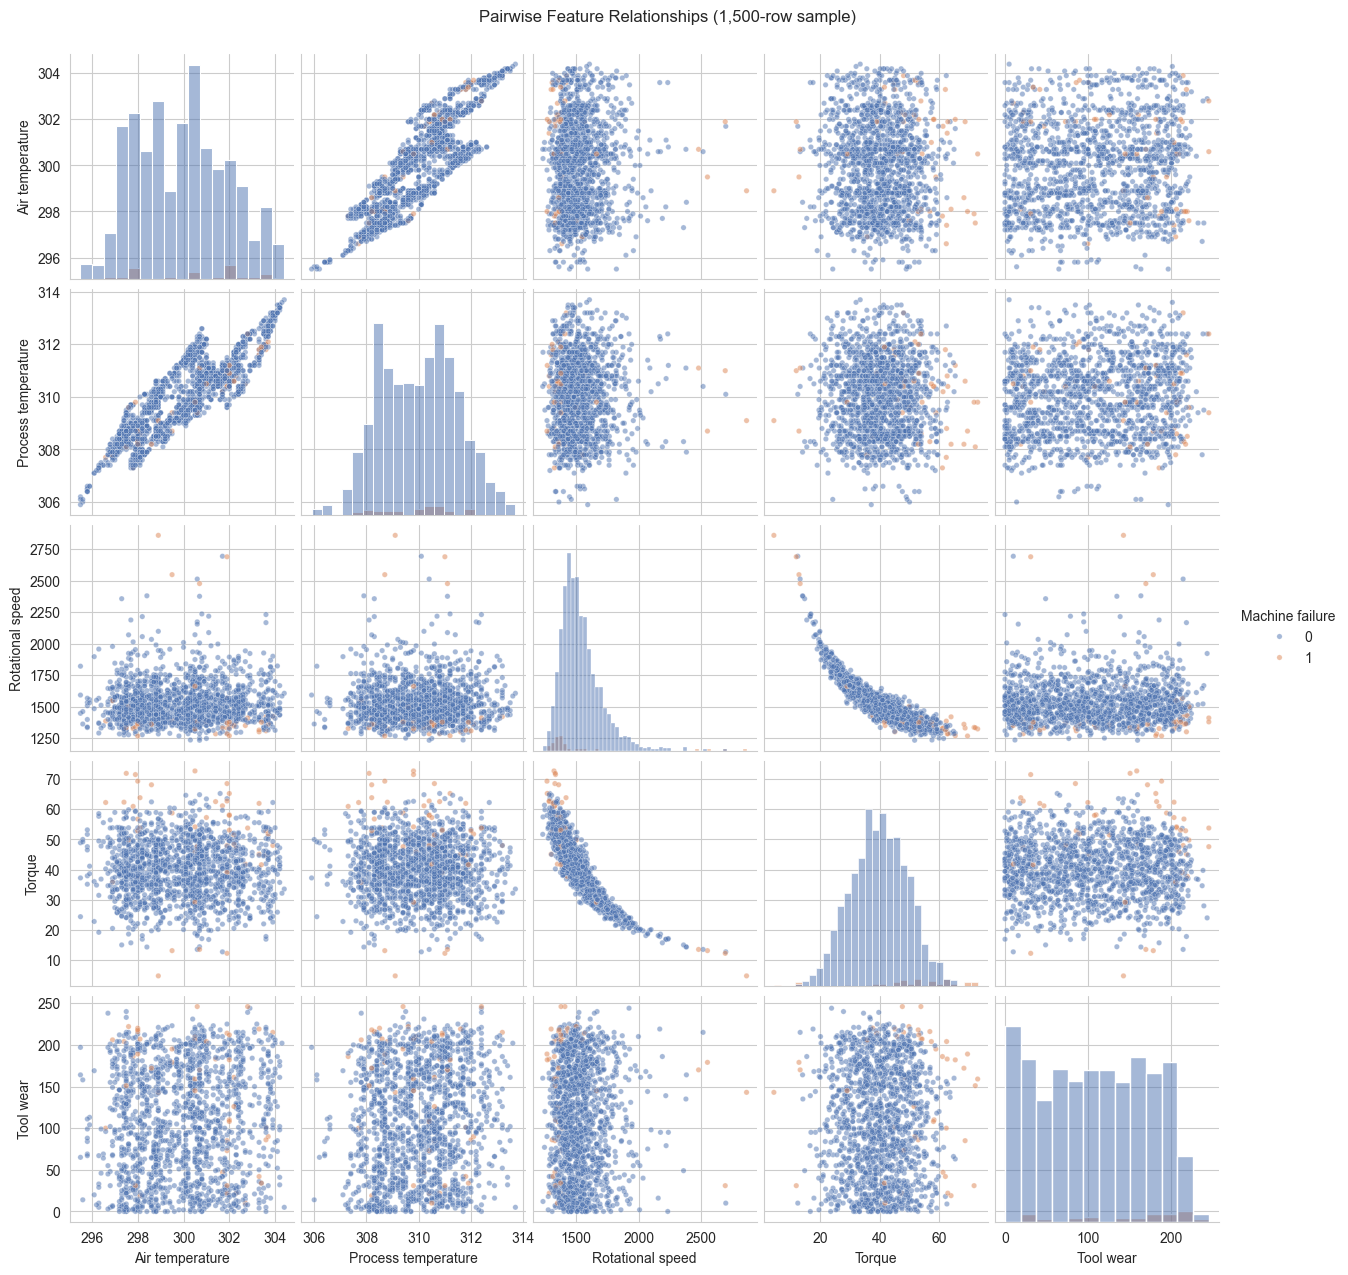

In [59]:
# Pairplot is expensive on 10,000 rows -- sample for a readable, fast plot
sample_df = df.sample(1500, random_state=42)
sns.pairplot(sample_df, vars=numeric_cols, hue="Machine failure",
             palette=["#4C72B0", "#DD8452"], plot_kws={"alpha":0.5, "s":15}, diag_kind="hist")
plt.suptitle("Pairwise Feature Relationships (1,500-row sample)", y=1.02)
plt.show()


**Observation:** No single pair of raw features perfectly separates the two classes visually (expected — that's exactly why we need a model), but failures (orange) visibly cluster at the extremes of torque and tool wear, matching §7.2.

## 8. Feature Engineering

Based on everything above, we now prepare the final feature set:

| Action | Column(s) | Reason |
|---|---|---|
| Drop | `UDI`, `Product ID` | Unique identifiers, no predictive value (§3.4) |
| Drop | `TWF`,`HDF`,`PWF`,`OSF`,`RNF` | Data leakage — directly define the target (§3.5) |
| Encode | `Type` | Categorical → numeric |
| Engineer | `Temperature difference` = Process temp − Air temp | Reduces redundancy from the two highly-correlated temperature columns (§7.1) while keeping the informative part (the *difference* is what drives heat-dissipation failure) |
| Keep as-is | `Air temperature`, `Process temperature`, `Rotational speed`, `Torque`, `Tool wear` | All shown to carry signal in EDA |


In [60]:
# Drop UDI and Product ID if they exist, always drop failure modes
cols_to_drop = failure_mode_cols.copy()
if "UDI" in df.columns:
    cols_to_drop.append("UDI")
if "Product ID" in df.columns:
    cols_to_drop.append("Product ID")
    
df_clean = df.drop(columns=cols_to_drop).copy()

# Feature engineering: temperature difference (captures heat-dissipation risk directly)
df_clean["Temp difference"] = df_clean["Process temperature"] - df_clean["Air temperature"]

# One-hot encode Type (L/M/H) -- standard approach for SVM / Logistic Regression
df_clean = pd.get_dummies(df_clean, columns=["Type"], prefix="Type", drop_first=True)
# drop_first=True avoids the "dummy variable trap" (perfect multicollinearity between dummy columns)

df_clean.head()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,Temp difference,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,10.5,False,True
1,298.2,308.7,1408,46.3,3,0,10.5,True,False
2,298.1,308.5,1498,49.4,5,0,10.4,True,False
3,298.2,308.6,1433,39.5,7,0,10.4,True,False
4,298.2,308.7,1408,40.0,9,0,10.5,True,False


**Why one-hot encoding and not label encoding (0/1/2)?** `Type` is a *nominal* category (L, M, H have no inherent numeric order that we want the model to assume — even though quality does have an order, treating it as raw integers 0/1/2 would force the model to assume M is exactly "twice" L, which isn't necessarily true for linear models like Logistic Regression / linear SVM). One-hot encoding avoids injecting a false numeric relationship. `drop_first=True` drops one dummy column to avoid redundant, perfectly collinear columns.

## 9. Train / Test Split

We split **before** scaling, and use **stratified** sampling on the target so that the ~3.4% failure rate is preserved in both the train and test sets (important given the class imbalance found in §4 — a random, non-stratified split risks a test set with very few or even zero failure examples).


In [61]:
from sklearn.model_selection import train_test_split

X_final = df_clean.drop(columns=["Machine failure"])
y_final = df_clean["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

print("Train shape:", X_train.shape, " Failure rate:", y_train.mean().round(4))
print("Test shape :", X_test.shape,  " Failure rate:", y_test.mean().round(4))


Train shape: (8000, 8)  Failure rate: 0.0339
Test shape : (2000, 8)  Failure rate: 0.034


## 10. Feature Scaling

**Why we must scale for SVM / Logistic Regression:** these algorithms optimise a distance- or margin-based objective. `Rotational speed [rpm]` ranges into the thousands while `Tool wear [min]` ranges 0–250 and `Temp difference [K]` is close to a handful of degrees — without scaling, high-magnitude features (like rpm) would dominate the distance/gradient calculations purely because of their units, not their actual importance. Tree-based models (Decision Trees/Random Forest) don't need this, but since SVM and Logistic Regression are the target models here, scaling is essential.

We fit the scaler **only on the training data** and apply it to both train and test — fitting on the full dataset (including test) would leak information about the test set's distribution into training (a subtle form of data leakage).


In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_features_to_scale = ["Air temperature", "Process temperature", "Rotational speed",
                          "Torque", "Tool wear", "Temp difference"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_features_to_scale] = scaler.fit_transform(X_train[num_features_to_scale])
X_test_scaled[num_features_to_scale] = scaler.transform(X_test[num_features_to_scale])

X_train_scaled.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
Air temperature,1.758593e-15,1.000063,-2.356591,2.250967
Process temperature,1.053468e-14,1.000063,-2.910801,2.564616
Rotational speed,3.010925e-16,1.000063,-2.052017,7.441184
Torque,-1.474376e-16,1.000063,-3.613500,3.652753
Tool wear,-3.064216e-17,1.000063,-1.692947,2.284539
Temp difference,-3.383960e-16,1.000063,-2.401113,2.099825


## 11. Class Imbalance — Options for the Modelling Stage

We measured in §4 that only 3.4% of samples are failures. We do **not** resample here (that decision belongs in the modelling notebook, applied *only* to the training fold, to avoid leaking synthetic/duplicated information into the test set), but we note the options for the lecturer/next stage:

- `class_weight="balanced"` in `LogisticRegression` / `SVC` — reweights the loss function so minority-class errors count more, no synthetic data needed. Usually the first thing to try.
- **SMOTE** (Synthetic Minority Oversampling) — generates synthetic minority-class samples; must be applied only to the training set, after the split, to avoid leakage.
- **Random undersampling** of the majority class — simple, but throws away data.
- Regardless of technique chosen, **accuracy should not be the primary metric** — use precision, recall, F1-score, and ROC-AUC / PR-AUC .


## 12. Export Cleaned & Split Data

Finally, we save the processed, split, and scaled datasets so the modelling notebook (SVM, Logistic Regression, etc.) can simply load them without repeating this work.


In [63]:
X_train_scaled.to_csv("X_train_scaled.csv", index=False)
X_test_scaled.to_csv("X_test_scaled.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# also save the unscaled clean version, useful for tree-based models later
df_clean.to_csv("ai4i2020_clean.csv", index=False)

print("Saved: X_train_scaled.csv, X_test_scaled.csv, y_train.csv, y_test.csv, ai4i2020_clean.csv")


Saved: X_train_scaled.csv, X_test_scaled.csv, y_train.csv, y_test.csv, ai4i2020_clean.csv


## 13. Summary — What We Did and Why

| Step | What we did | Why |
|---|---|---|
| Load data | Loaded via official `ucimlrepo` API (with CSV fallback) | Reproducible, official source; matches UCI's citation guidance |
| Inspect | Checked shape, dtypes, `describe()` | Establish a baseline understanding before changing anything |
| Missing values | Checked with `isnull().sum()` | Found **0 missing values** — nothing to impute |
| Duplicates | Checked with `duplicated().sum()` | Found **0 duplicate rows** — nothing to drop |
| Range check | Verified min/max of all numeric sensors | Found no impossible/invalid values |
| Drop identifiers | Dropped `UDI`, `Product ID` | Unique IDs carry zero predictive/generalisable signal |
| Drop leakage columns | Dropped `TWF, HDF, PWF, OSF, RNF` | These directly define the target — leaving them in would leak the answer and make evaluation meaningless |
| Target analysis | Value counts + plots | Found **severe class imbalance (~3.4% failures)** — shapes our choice of evaluation metric and future resampling strategy |
| Outlier detection | IQR method per numeric feature | Found outliers correlate strongly with **real failures**, not data errors → kept them |
| Categorical EDA | Distribution + failure rate of `Type` | Confirmed L/M/H matches documented 50/30/20% split; `L` has a higher failure rate → keep as a feature |
| Correlation analysis | Heatmap + boxplots split by class | Found air/process temperature are collinear; torque & tool wear separate the classes best |
| Feature engineering | One-hot encoded `Type`; engineered `Temp difference` | Prepares categorical data for numeric-only algorithms (SVM/LogReg); reduces redundant collinearity while preserving signal |
| Train/test split | 80/20, **stratified** on target | Preserves the rare failure class proportionally in both sets |
| Scaling | `StandardScaler`, fit on train only | SVM and Logistic Regression are scale-sensitive; fitting only on train avoids leaking test-set statistics |
| Imbalance handling | Documented options (`class_weight`, SMOTE) but deferred | Belongs at the modelling stage; must only touch the training fold |
| Export | Saved train/test splits + clean full dataset to CSV | Lets the modelling notebook (SVM, Logistic Regression, etc.) start immediately from clean, ready-to-use data |

**Bottom line:** the dataset was already very clean (synthetic, no missing values/duplicates), so most of the work here was about **understanding the data** (EDA), **removing leakage**, and **preparing it correctly for the specific algorithms we plan to use** (encoding + scaling for SVM/Logistic Regression), rather than heavy-duty cleaning.
